# 01 - Exploratory Data Analysis

Credit Card Fraud Detection. Run from the project root or the `notebooks/` folder.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make project root importable and locate data regardless of cwd.
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
FIGURES = os.path.join(ROOT, 'reports', 'figures')
os.makedirs(FIGURES, exist_ok=True)

from src.preprocess import load_data

df = load_data()
df.shape

(284807, 31)

## 1. Dataset Overview

In [2]:
df.info()
display(df.describe())
print('Nulls:', df.isnull().sum().sum())
print('\nClass distribution:')
print(df['Class'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Nulls: 0

Class distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


## 2. Class Imbalance Visualization

C:\Users\krish\AppData\Local\Temp\ipykernel_30948\123361766.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Legit (0)', 'Fraud (1)'])


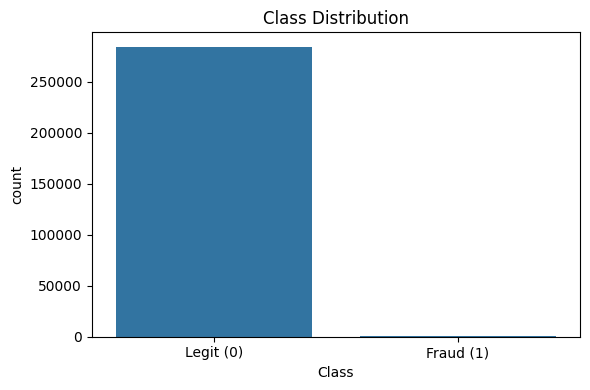

Imbalance ratio (legit:fraud) = 577.9 : 1


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Class', data=df, ax=ax)
ax.set_xticklabels(['Legit (0)', 'Fraud (1)'])
ax.set_title('Class Distribution')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'class_distribution.png'), dpi=150)
plt.show()

imbalance = (df['Class'] == 0).sum() / (df['Class'] == 1).sum()
print(f'Imbalance ratio (legit:fraud) = {imbalance:.1f} : 1')

## 3. Feature Distributions

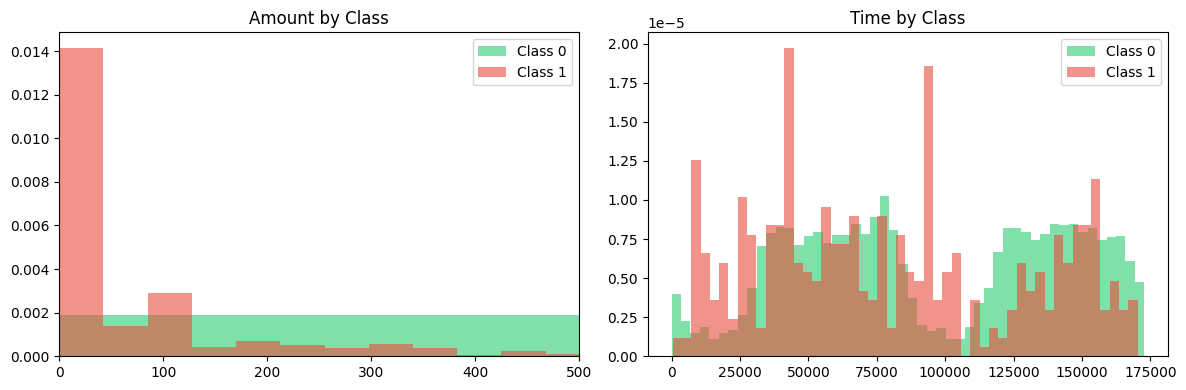

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cls, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    axes[0].hist(df[df['Class'] == cls]['Amount'], bins=50, alpha=0.6, label=f'Class {cls}', color=color, density=True)
    axes[1].hist(df[df['Class'] == cls]['Time'], bins=50, alpha=0.6, label=f'Class {cls}', color=color, density=True)
axes[0].set_title('Amount by Class'); axes[0].legend(); axes[0].set_xlim(0, 500)
axes[1].set_title('Time by Class'); axes[1].legend()
plt.tight_layout()
plt.show()

Top 5 features correlated with Class: ['V17', 'V14', 'V12', 'V10', 'V16']


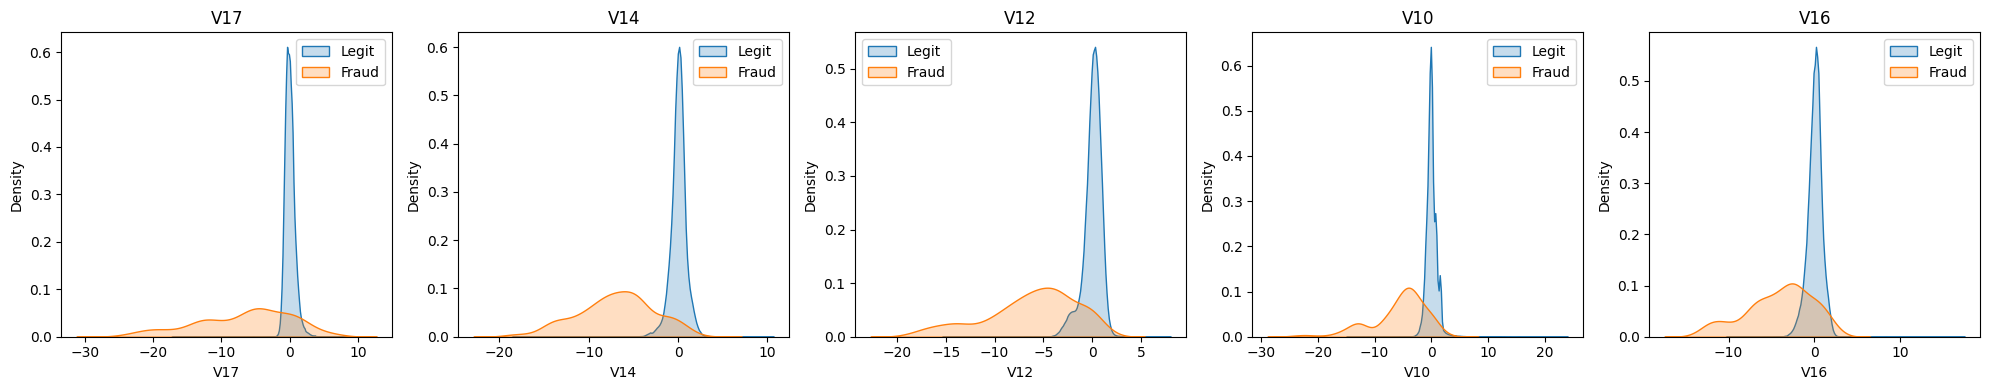

In [5]:
top5 = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(5).index.tolist()
print('Top 5 features correlated with Class:', top5)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, top5):
    sns.kdeplot(df[df['Class'] == 0][feat], ax=ax, label='Legit', fill=True)
    sns.kdeplot(df[df['Class'] == 1][feat], ax=ax, label='Fraud', fill=True)
    ax.set_title(feat); ax.legend()
plt.tight_layout()
plt.show()

## 4. Correlation Heatmap

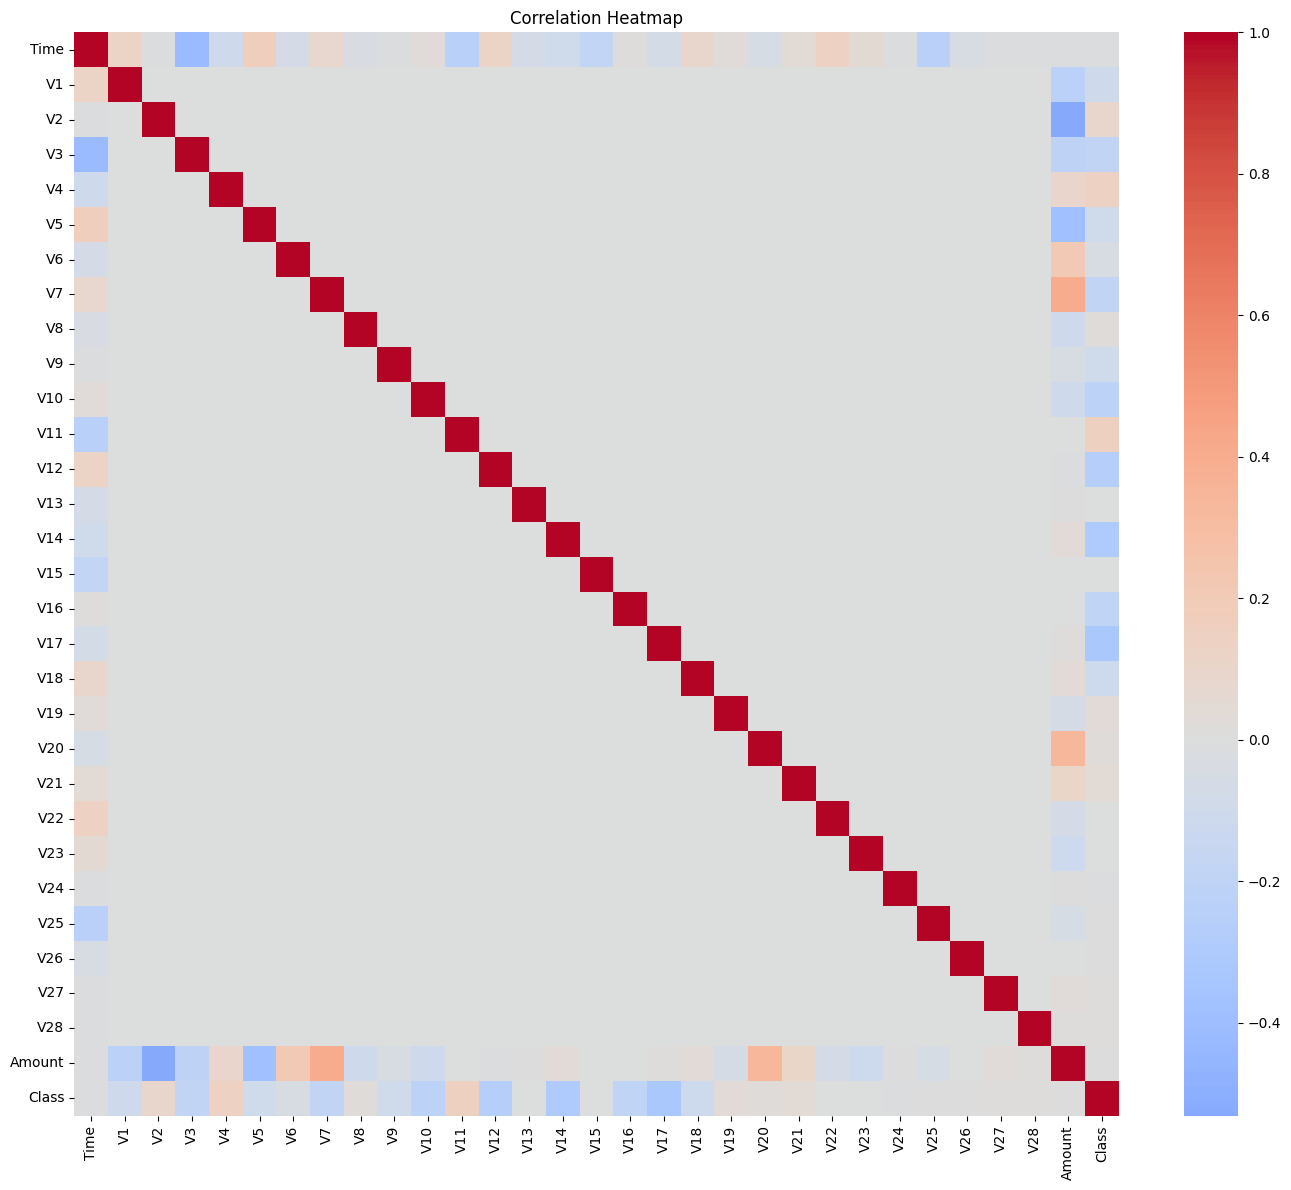

Features most correlated with Class:


V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'correlation_heatmap.png'), dpi=150)
plt.show()

print('Features most correlated with Class:')
print(df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False).head(10))

## 5. Key Findings

- **Imbalance:** frauds are ~0.17% of all transactions (roughly 578:1 legit:fraud).
- **Top correlated features:** typically V17, V14, V12, V10, V16 (negative) drive fraud signal.
- **Amount/Time:** fraud amounts skew lower on average; time-of-day shows mild patterns.
- **Implication:** use SMOTE / class weights and evaluate with PR-AUC, not accuracy.